# [Basic] Quration Resource Estimation 

This document explains how to perform resource estimation at the instruction set level using [quration](https://github.com/quration/quration) for circuits written with qsub.

The overall workflow is as follows:
```
Write a circuit with qsub
↓
Convert the qsub circuit to a quration circuit
↓
Compile the quration circuit to ISA (instruction set)
↓
Perform resource estimation on the compiled code using qret
```


In [ ]:
# If quri-parts is not installed, install it with the following command:
# %pip install quri-parts


### Write a 2-qubit CNOT circuit with Qsub


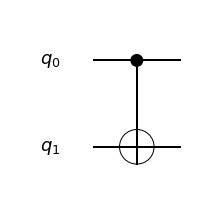

In [ ]:
from quri_parts.qsub.sub import SubBuilder
from quri_parts.qsub.lib.std import X, CNOT, Controlled
from quri_parts.qsub.visualize import draw
from quri_parts.qsub.resolve import resolve_sub

# Build a 2-qubit circuit
# b = SubBuilder(2)
# q0, q1 = b.qubits
# b.add_op(CNOT, (q0, q1))

ctrl = Controlled(X)
sub = resolve_sub(ctrl)
draw(sub)


### Resource Estimation with qsub (CNOT)


In [ ]:
# Compile the CNOT

from quri_parts.qsub.compile import compile_sub
from quri_parts.qsub.evaluate import Evaluator
from quri_parts.qsub.eval import GateCountEvaluatorHooks, TotalQubitCountEvaluatorHooks, QURIPartsEvaluatorHooks
from quri_parts.qsub.primitive import AllBasicSet

compiled = compile_sub(sub, AllBasicSet)
qubit_counter = Evaluator(TotalQubitCountEvaluatorHooks())
required_qubits = qubit_counter.run(compiled)
print(f"total qubit count: {required_qubits}")

gate_counter = Evaluator(GateCountEvaluatorHooks(AllBasicSet))
gate_count = gate_counter.run(compiled)
print({k[1]: v for k, v in gate_count.items()})


total qubit count: 2
{'CNOT': 1}


## Compilation to Surface Code / Lattice Surgery Architecture

### What is an ISA (Instruction Set Architecture)?

The Quration compiler outputs **ISA (Instruction Set Architecture) code**. An ISA is a set of low-level instructions that a specific hardware architecture can execute directly. Here it targets instructions specific to the surface code / lattice surgery architecture (such as `LATTICE_SURGERY` and `ALLOCATE`). Compiling refers to the conversion from a logical circuit to ISA.

### Compilation Flow

The Quration compiler converts a logical quantum circuit into a sequence of instructions on the surface code / lattice surgery architecture. The process consists of three stages:

### 1. Mapping

Assigns logical qubits to logical cells (coordinates) on the chip.

### 2. Routing

Lattice surgery between non-adjacent logical qubits is implemented as a chain of lattice surgery operations via path cells.
The difference between `runtime` and `runtime_without_topology` corresponds to this routing overhead.

### 3. Scheduling and Profiling

Simulates the lattice surgery instruction sequence beat by beat (timestep by timestep) and computes performance metrics such as execution time, number of physical qubits, and magic state consumption count.
To convert to wall-clock time (seconds), the code cycle time (`code_cycle_time_sec`) — calibrated for a superconducting device — is specified in the pipeline.

---

### Example: Conversion of a Logical CNOT to Lattice Surgery

A logical CNOT is realized as two parity measurements, ZZ and XX.

```
Logical CNOT(q0→q1)
  ↓
[beat 0]  LATTICE_SURGERY [q1, q0]  ZZ measurement  → classical bit c10
[beat 1]  LATTICE_SURGERY [q1, q0]  XX measurement  → classical bit c11
```

Each measurement result (c10, c11) determines whether a byproduct Pauli correction is needed. However, since CNOT is a Clifford gate, the byproduct can be classically tracked via Pauli frame tracking and no actual quantum correction operation is required (`measurement_feedback_count = 0`).

The `compiled_cnot.json` inspected in a later step contains these two `LATTICE_SURGERY` instructions.


### Resource Estimation with quration


Temporary setup instructions for quri-parts-qret and quration-cli-bundle

- The feature to convert from qsub to quration IR will be provided in the `quri-parts-qret` package.
- The quration CLI can be installed via the `quration-cli-bundle` package.


In [ ]:
# You may need to uninstall existing packages before installing.

# Install qsub
# %pip install git+https://github.com/QunaSys/quri-sdk-internal.git@quri-parts-qret-temp#subdirectory=quri-parts/packages/qsub

# Install qret-cli-bundle
# %pip install git+https://github.com/QunaSys/quration-cli-bundle.git

# Install quri-parts-qret
# %pip install git+https://github.com/QunaSys/quri-sdk-internal.git@quri-parts-qret-temp#subdirectory=quri-parts/packages/qret


In [ ]:
import qret_cli_bundle
qret_cli_bundle.ensure_qret_on_path()
import quri_parts.qret.convert_qsub as converter
import pyqret

cnot_module = converter.create_module_from_qsub_op(entry_op=ctrl)

# Dump the converted quration IR to a JSON file
cnot_module.dump("cnot/cnot_ir.json")


In [ ]:
import json

def beautifyJSON(filename):
    with open(filename, "r") as f:
        data = json.load(f)
    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

beautifyJSON("cnot/cnot_ir.json")

In [ ]:
%cat cnot/cnot_ir.json

{
    "metadata": {
        "format": "IR",
        "schema_version": "0.1",
        "qret_version": "1.0.1",
        "created_at": "2026-04-15T13:18:46"
    },
    "name": "__qsub__lib.std.Controlled<lib.std.X>",
    "circuit_list": [
        {
            "name": "main",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Call",
                            "callee": "lib.std.Controlled<lib.std.X>",
                            "operate": [
                                0,
                                1
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "Return"
                        }
                    ],
                    "predecessors": [],
                    

### Defining the Topology

Before compilation, you need to define the layout of **logical qubits** and **magic factories** on the chip. Quration calls this the "topology".

There are three types of cells in a topology:

| Cell type | Role | How to configure |
|-----------|------|-------------------|
| **Data logical qubit cell** (Q) | Location of the algorithm's logical qubits | Placed automatically by qret |
| **Ancilla cell** (.) | Ancilla cells used as routing paths for lattice surgery | Placed automatically by qret |
| **Magic factory cell** (M) | Cells that produce magic states required for T-gates | Must be defined in the topology file |

```
M . M . M    (M = magic factory, Q = qubit, . = bus/routing cell)
. . . . .
Q . Q . Q
. . . . .
Q . Q . .
```

The topology file can be auto-generated from the qubit count estimated on the qsub side, or prepared manually.
- Required qubit count = input/output qubit count + auxiliary qubit count
- Auto-generated topology files may have room for optimization.


In [ ]:
import quri_parts.qret.topology_utils as topology
topology.write_generated_topology("cnot/topology_for_cnot.yaml", required_qubits, magic_factory_count=1)

PosixPath('cnot/topology_for_cnot.yaml')

In [ ]:
%cat cnot/topology_for_cnot.yaml

grids:
  - type: plane
    coord: [3, 3, 0]
    magic_factory:
      - symbol: 0
        coord: [0, 0]


### Compile the quration IR to ISA

First confirm that qret cli is on the PATH, then compile using the pipeline file.


In [ ]:
import qret_cli_bundle
qret_cli_bundle.ensure_qret_on_path()

To compile an IR file to the ISA (instruction set) level using the qret CLI, you need to prepare a pipeline file.

The pipeline mainly specifies:
- `source`: format of the input file (IR, QASM, etc.)
- `input`: input file path
- `output`: output file path
- `target`: target machine architecture
- `function`: name of the entry-point function in the circuit. When converting from qsub, `main` can usually be specified.
- `sc_ls_fixed_v0_topology`: topology file path

At the moment, the pipeline file must be prepared manually.

Detailed documentation of pipeline parameters is available at:

https://github.com/QunaSys/quration/blob/kaz/pipeline-doc/quration-docs/pipeline-yaml.md#L0-L1


In [ ]:
# Contents of cnot_pipeline.yaml
%cat cnot/cnot_pipeline.yaml


source: IR
input: cnot/cnot_ir.json
function: main
target: SC_LS_FIXED_V0
output: cnot/compiled_cnot.json
sc_ls_fixed_v0_topology: cnot/topology_for_cnot.yaml
sc_ls_fixed_v0_machine_type: Dim2
sc_ls_fixed_v0_magic_generation_period: 15
sc_ls_fixed_v0_maximum_magic_state_stock: 10000
sc_ls_fixed_v0_entanglement_generation_period: 100
sc_ls_fixed_v0_maximum_entangled_state_stock: 10
sc_ls_fixed_v0_reaction_time: 1
sc_ls_fixed_v0_drop_rate: 0.1
sc_ls_fixed_v0_code_cycle_time_sec: 0.00000001
sc_ls_fixed_v0_physical_error_rate: 0.01
sc_ls_fixed_v0_allowed_failure_prob: 0.01
sc_ls_fixed_v0_pass:
  - sc_ls_fixed_v0::init_compile_info
  - sc_ls_fixed_v0::mapping
  - sc_ls_fixed_v0::routing


In [ ]:
%%sh
# Compile cnot_ir.json
qret compile --pipeline cnot/cnot_pipeline.yaml 


Profile the generated ISA file


In [ ]:
%%sh
# Profile cnot_ir.json
qret profile -i cnot/compiled_cnot.json  -o cnot/profiled_cnot.json


### Viewing Profiling Results with the Quration Visualizer


#### Computational Process Visualizer
Visualizes the **execution trace (computational process)** of a quantum program. You can follow the execution status of instructions beat by beat (timestep by timestep) in an animated fashion.

Launch the computational process visualizer and load `compiled_cnot.json` from the Web UI.


In [ ]:
qret_cli_bundle.visualize_computational_process()

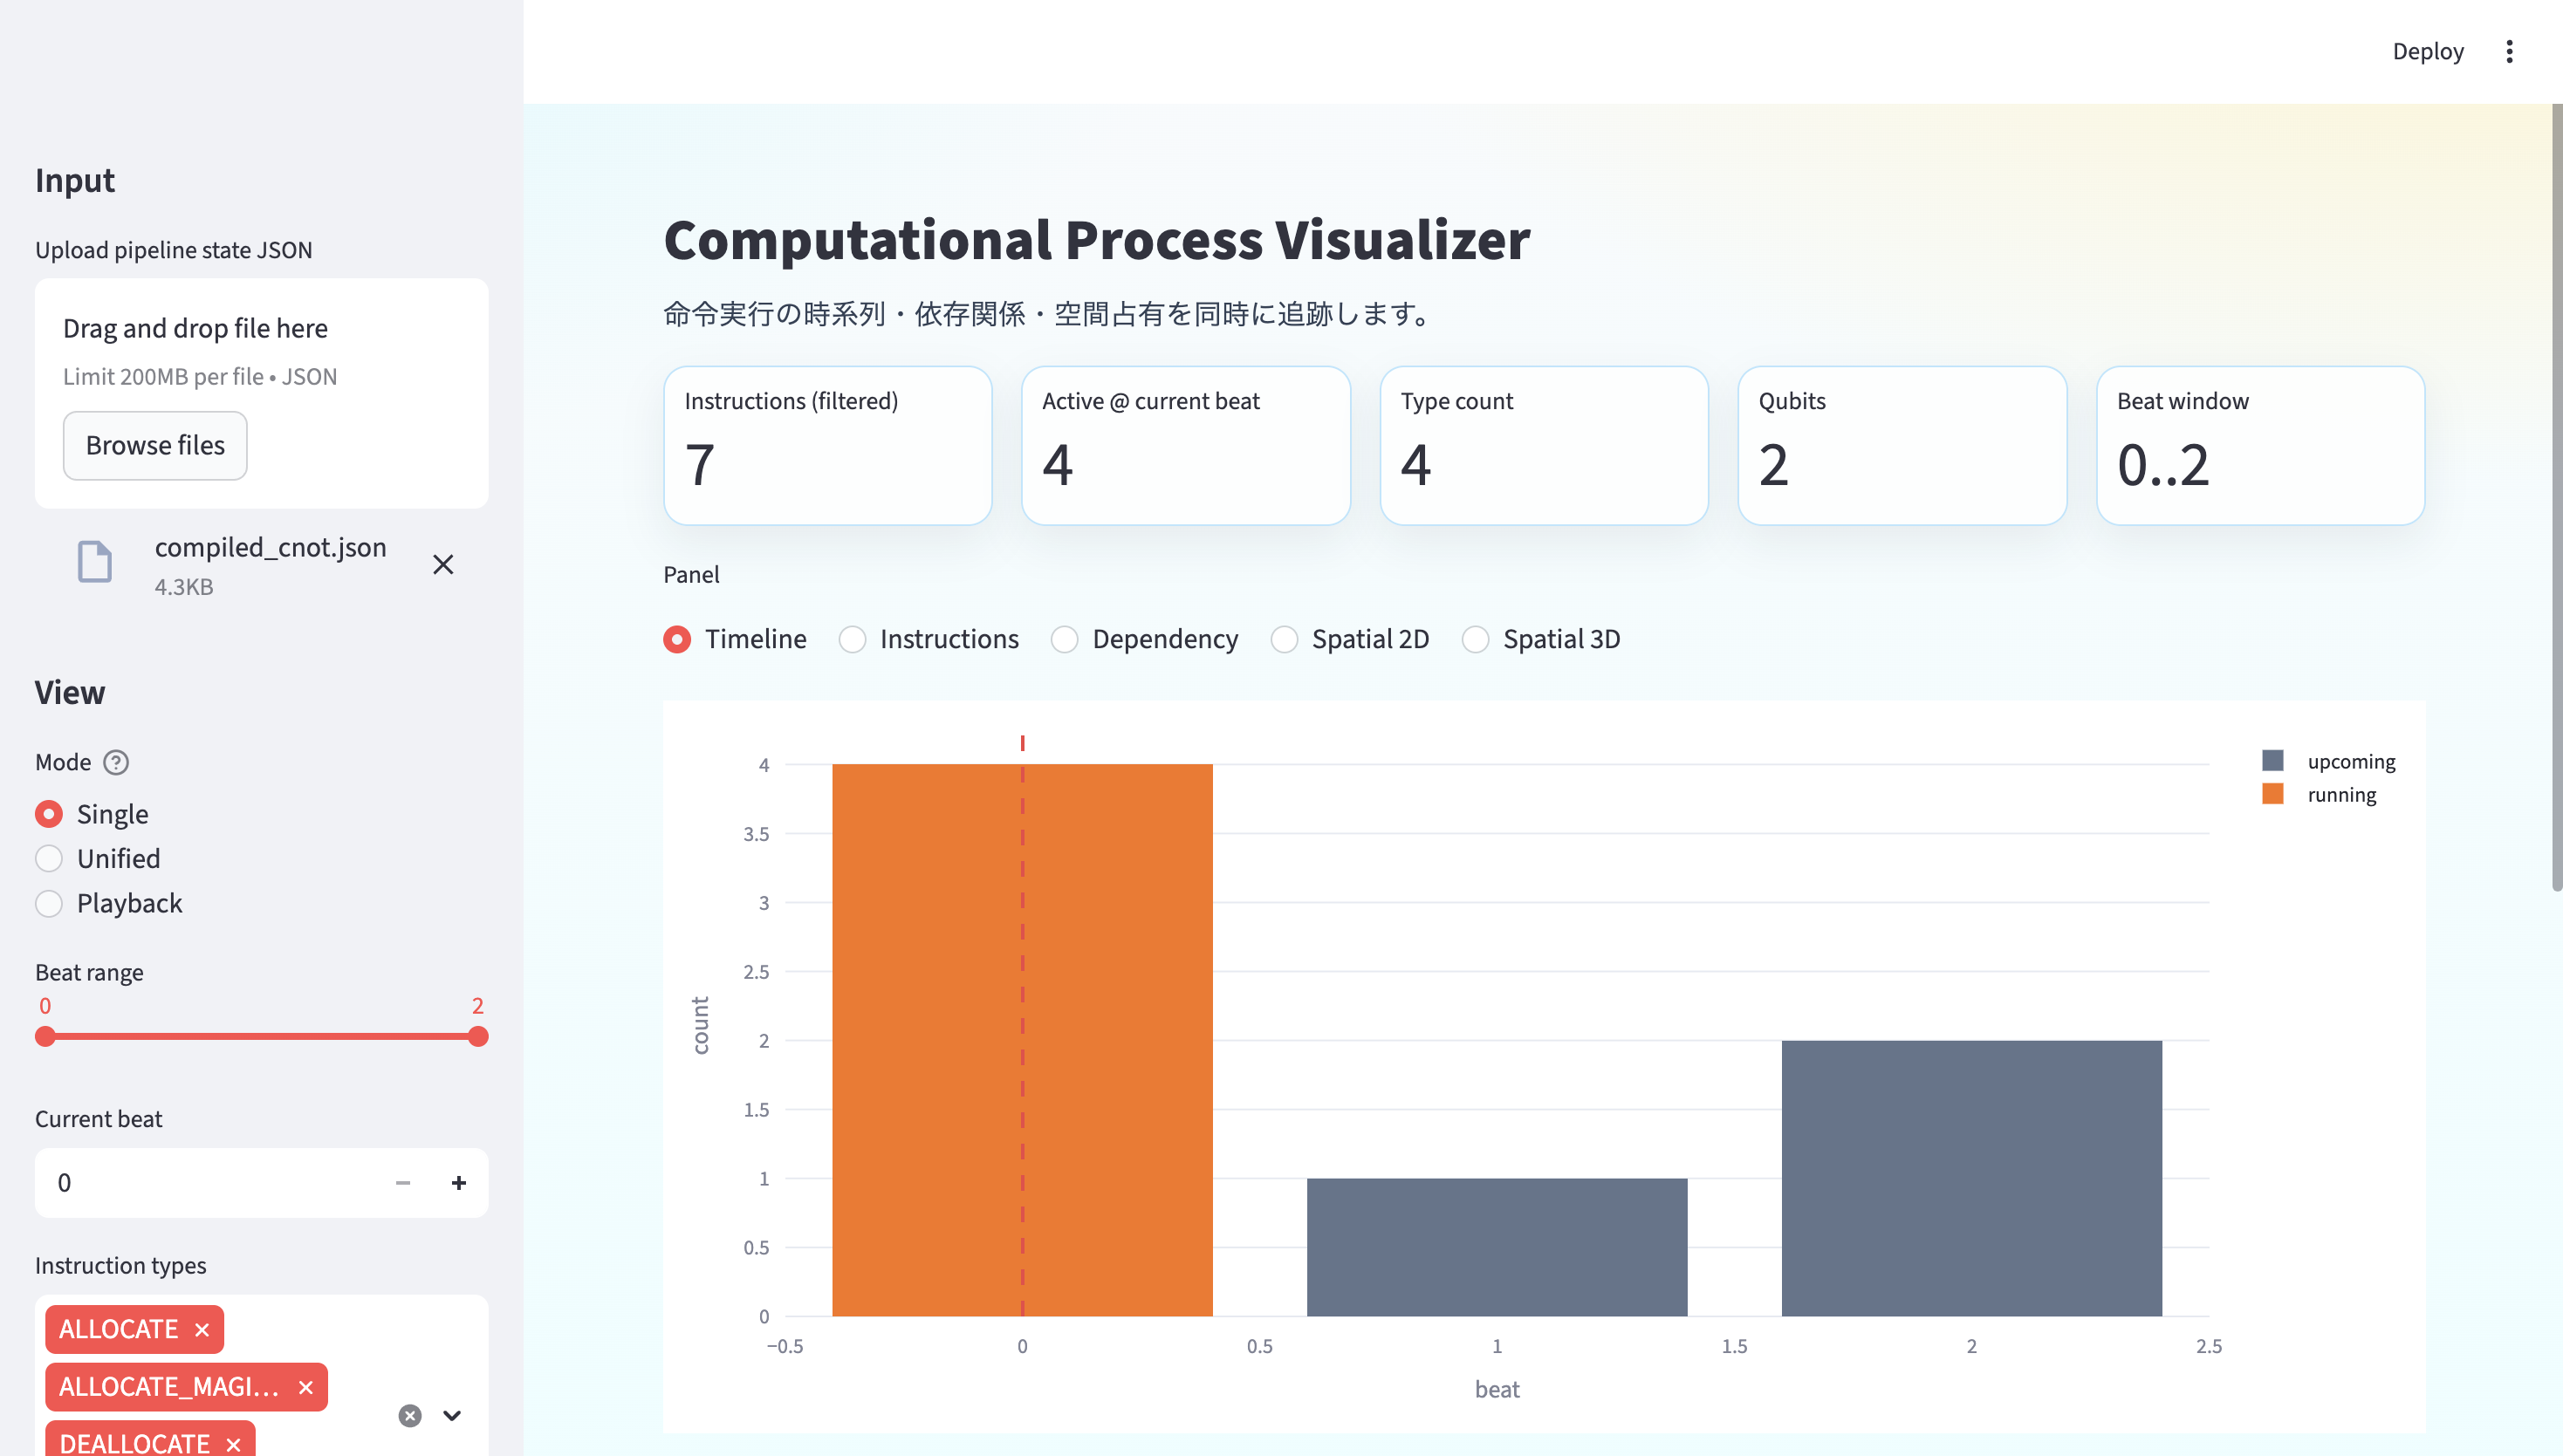

### Compile Info Visualizer

Displays and compares various information from post-compilation profile data across multiple profiles simultaneously.

Load `profiled_cnot.json` from the Web UI to view the profile information.


In [ ]:
qret_cli_bundle.visualize_compile_info()

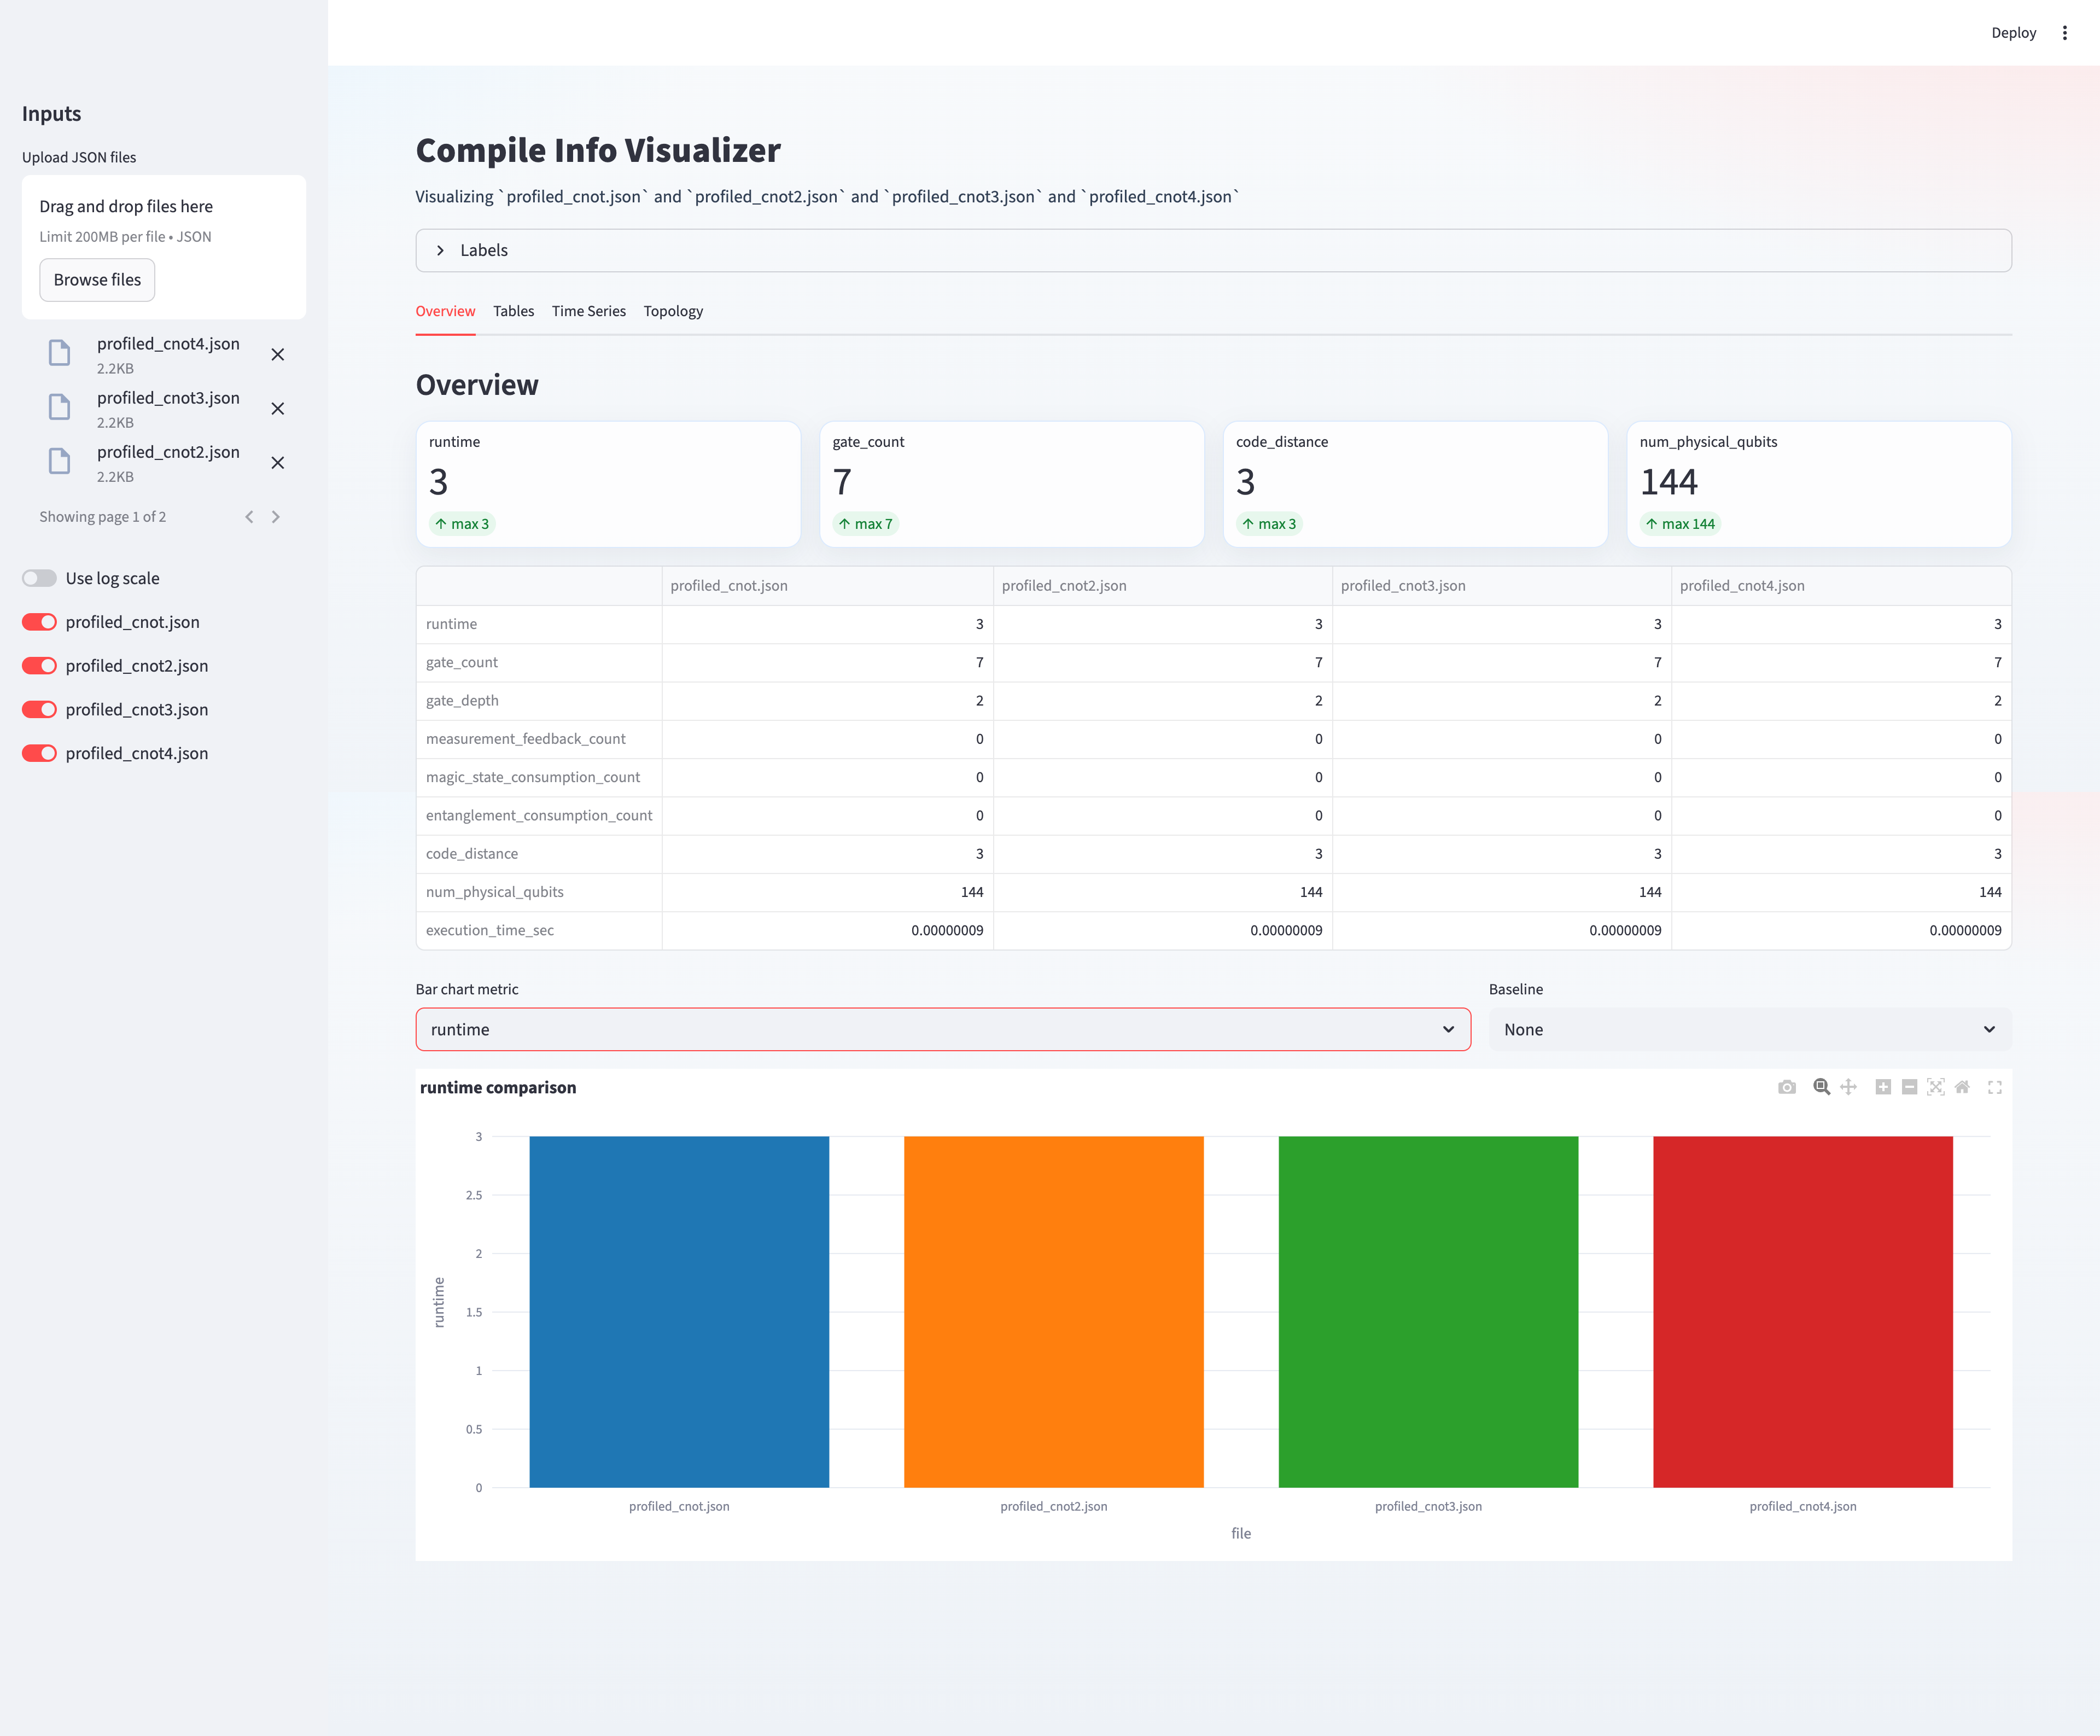

#### Key Metrics in Compile Info

The table below summarizes the metrics displayed in the compile info visualizer.

##### Runtime metrics

| Metric | Meaning | Why it matters |
|--------|---------|----------------|
| `execution_time_sec` | Total execution time (seconds) calculated from the parameters given at compile time | The final metric for judging circuit practicality |
| `runtime` | Total beat count (number of timesteps) including topology constraints | Actual runtime after hardware placement and routing |
| `runtime_without_topology` | Total beat count without topology constraints | A large difference from `runtime` indicates higher routing overhead |

##### Hardware cost metrics

| Metric | Meaning | Why it matters |
|--------|---------|----------------|
| `num_physical_qubits` | Total number of physical qubits required | Direct measure of hardware scale |
| `code_distance` | Error-correcting code distance | Determined by `physical_error_rate` and `allowed_failure_prob`. Larger values increase the physical-to-logical qubit ratio |
| `chip_cell_count` | Total number of cells on the chip excluding magic factories | Size of the physical layout |
| `chip_cell_algorithmic_qubit_ratio_peak` | Peak fraction of chip area occupied by algorithmic qubits | Lower values indicate worse space efficiency (more cells used for routing/factories) |
| `qubit_volume` | Cumulative sum over beats of the number of active qubits (logical + ancilla) | Measure of the spacetime volume of the algorithm. Used to compare implementations |

##### Magic state metrics

In fault-tolerant quantum computing (FTQC), T-gates — unlike Clifford gates — cannot be executed directly within an error-correcting code and require a procedure called "magic state injection". The T-gate count is a lower bound on the number of magic states consumed, but the two may not match depending on the Toffoli decomposition method and the `use_magic_state_cultivation` setting.

| Metric | Meaning | Why it matters |
|--------|---------|----------------|
| `magic_state_consumption_count` | Total number of magic states consumed during logical circuit execution | The most dominant metric for algorithm complexity. Primary target for algorithm improvement |
| `magic_state_consumption_depth` | Depth of the dependency chain of magic state consumption (number of serialized layers) | A lower bound that cannot be reduced by parallelization. Only reducing the sequential structure of the algorithm helps |
| `magic_state_consumption_rate_ave` | Average magic state consumption per unit time | Used to cross-check against the supply capacity of the magic state factory |
| `magic_state_consumption_rate_peak` | Peak magic state consumption per unit time | If peak demand exceeds factory supply, queueing occurs and `execution_time_sec` increases |
| `magic_factory_count` | Number of magic state factories | The number of "factories" supplying magic states. Increasing this raises supply capacity but also increases space cost |

##### Measurement feedback metrics

These are classical feedback operations to correct byproducts (Pauli errors) that arise during logical gate implementation via lattice surgery. Note that syndrome measurements (stabilizer measurements for error correction) are *not* counted here — qret already accounts for them as a fixed one-code-cycle overhead. Measurement feedback is constrained by classical control system latency (`reaction_time`) and therefore directly affects runtime.

| Metric | Meaning | Why it matters |
|--------|---------|----------------|
| `measurement_feedback_count` | Total number of operations involving measurement feedback | Scale of the adaptive circuit |
| `measurement_feedback_depth` | Depth of measurement feedback operations | `reaction_time` × `measurement_feedback_depth` contributes to the lower bound of runtime |
| `measurement_feedback_rate_peak` | Peak frequency of feedback | Used to diagnose bottlenecks in the classical control system |

##### Gate statistics

| Metric | Meaning | Why it matters |
|--------|---------|----------------|
| `gate_count` | Total number of logical gates | Basic measure of circuit size |
| `gate_count_detail` | Breakdown by gate type | The ratio of T-gates to Clifford gates gives a rough estimate of FTQC cost |
| `gate_depth` | Logical circuit depth (number of gate operations that must be executed sequentially) | Correlated with runtime. The more gates can be parallelized, the smaller `gate_depth` becomes |
